<a href="https://colab.research.google.com/github/mob238956-ops/horse-or-human/blob/main/horse_or_human.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#My dataset is available in googledrive; so I am accessing my drive from colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#Once this is executed, you will see your drive appearing on the left hand side

Mounted at /content/drive


In [ ]:
# Define paths to the dataset
train_dir = '/content/drive/MyDrive/train'  # Update with your actual path
test_dir = '/content/drive/MyDrive/test'    # Update with your actual path

In [ ]:
import os
print(len(os.listdir('/content/drive/MyDrive/train/horses')))
print(len(os.listdir('/content/drive/MyDrive/train/humans')))
print(len(os.listdir('/content/drive/MyDrive/test/horses')))
print(len(os.listdir('/content/drive/MyDrive/test/humans')))

500
527
500
527


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation / feature scaling
    validation_split=0.2  # Split 20% of the images for validation
)

# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (cats vs. dogs)
    subset='training'  # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Load and prepare validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Specify 'validation' for the validation set
)

Found 822 images belonging to 2 classes.
Found 205 images belonging to 2 classes.


In [ ]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [ ]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output laye

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification


In [ ]:
history = model.fit(train_data, epochs=5, validation_data=validation_data)

Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 151s 6s/step - accuracy: 0.7664 - loss: 0.5185 - val_accuracy: 0.9415 - val_loss: 0.2458
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 121s 5s/step - accuracy: 0.9209 - loss: 0.2629 - val_accuracy: 0.9659 - val_loss: 0.0936
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 134s 5s/step - accuracy: 0.9805 - loss: 0.0479 - val_accuracy: 0.9659 - val_loss: 0.0859
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.9891 - loss: 0.0295 - val_accuracy: 0.9707 - val_loss: 0.0663
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.9988 - loss: 0.0099 - val_accuracy: 0.9415 - val_loss: 0.1350


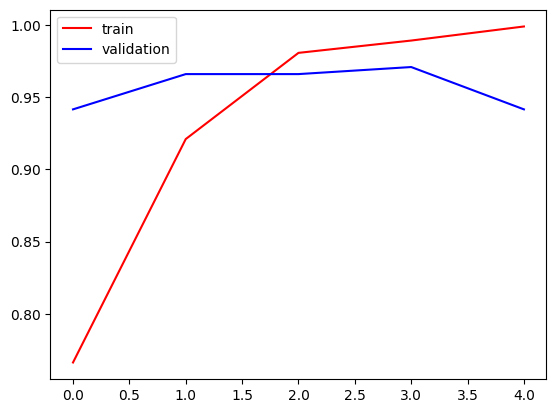

In [ ]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

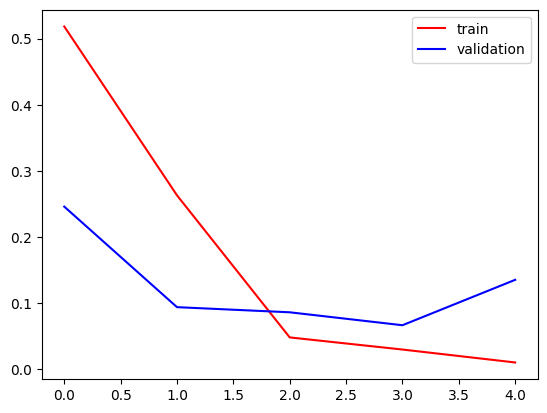

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 1027 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

33/33 ━━━━━━━━━━━━━━━━━━━━ 122s 4s/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report


true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)


cm = confusion_matrix(true_labels, predicted_labels)


print("Confusion Matrix:")
print(cm)


print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[241 259]
 [269 258]]
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.48      0.48       500
           1       0.50      0.49      0.49       527

    accuracy                           0.49      1027
   macro avg       0.49      0.49      0.49      1027
weighted avg       0.49      0.49      0.49      1027



In [ ]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output layer


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_data, epochs=5, validation_data=validation_data)

Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 198s 7s/step - accuracy: 0.8783 - loss: 2.3590 - val_accuracy: 0.6488 - val_loss: 3.4803
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 185s 7s/step - accuracy: 0.9757 - loss: 0.3375 - val_accuracy: 0.5512 - val_loss: 12.1240
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 184s 7s/step - accuracy: 0.9891 - loss: 0.2368 - val_accuracy: 0.6732 - val_loss: 10.9708
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 191s 7s/step - accuracy: 0.9891 - loss: 0.1267 - val_accuracy: 0.4878 - val_loss: 19.7044
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 186s 7s/step - accuracy: 0.9866 - loss: 0.1721 - val_accuracy: 0.5561 - val_loss: 10.3987


In [ ]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)


Found 1027 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

33/33 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[ 31 469]
 [ 33 494]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.48      0.06      0.11       500
           1       0.51      0.94      0.66       527

    accuracy                           0.51      1027
   macro avg       0.50      0.50      0.39      1027
weighted avg       0.50      0.51      0.39      1027



In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #all layers in the Resnet50 is not trainable; keep those weights; I am going to add my own i/p and other layers

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])


In [ ]:
history = resnet_model.fit(train_data, epochs=5, validation_data=validation_data)

Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 270s 10s/step - accuracy: 0.5779 - loss: 2.2292 - val_accuracy: 0.5610 - val_loss: 0.7494
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 228s 9s/step - accuracy: 0.8321 - loss: 0.3961 - val_accuracy: 0.6341 - val_loss: 0.6961
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 255s 9s/step - accuracy: 0.8929 - loss: 0.3023 - val_accuracy: 0.6927 - val_loss: 0.4984
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 232s 9s/step - accuracy: 0.8881 - loss: 0.2845 - val_accuracy: 0.8000 - val_loss: 0.3705
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 262s 10s/step - accuracy: 0.8844 - loss: 0.2705 - val_accuracy: 0.6829 - val_loss: 0.6219


In [ ]:
predictions = resnet_model.predict(test_data)

33/33 ━━━━━━━━━━━━━━━━━━━━ 227s 7s/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[306 194]
 [310 217]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.50      0.61      0.55       500
           1       0.53      0.41      0.46       527

    accuracy                           0.51      1027
   macro avg       0.51      0.51      0.51      1027
weighted avg       0.51      0.51      0.50      1027

